In [1]:
import os
import sys
import logging
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import ee

from download_sentinel2_mosaics import initialize_earthengine, s2_image_exporter, BANDS

In [2]:
initialize_earthengine()

In [3]:
test_cases = [
    {
        'name': 'California Agriculture (Summer)',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2023-06-01',
        'end': '2023-06-11',
        'collection': 'L2A'
    },
    {
        'name': 'California Agriculture (Summer) - L1C',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2023-06-01',
        'end': '2023-06-11',
        'collection': 'L1C'
    },
    {
        'name': 'California Agriculture (Winter) - 2017 - L2A',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2017-01-01',
        'end': '2017-01-31',
        'collection': 'L2A'
    },
    {
        'name': 'California Agriculture (Winter) - 2017 - L1C',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2017-01-01',
        'end': '2017-01-31',
        'collection': 'L1C'
    },
]

out_dir = './test_s2_images'

In [4]:
print("\n" + "="*70)
print("DOWNLOADING TEST IMAGES")
print("="*70 + "\n")

results = []

for i, test in enumerate(test_cases):
    print(f"\n[{i+1}/{len(test_cases)}] {test['name']}")
    print(f"  Location: ({test['lat']}, {test['lon']})")
    print(f"  Date range: {test['start']} to {test['end']}")
    print(f"  Collection: {test['collection']}")
    
    file_name = f"test_{i+1:02d}_{test['collection']}.tif"
    file_path = os.path.join(out_dir, file_name)
    
    # Skip if already downloaded
    if os.path.exists(file_path):
        print(f"  ⊙ Already exists, skipping download")
        results.append({'test': test, 'file_path': file_path, 'success': True})
        continue
    
    result = s2_image_exporter(
        lat=test['lat'],
        lon=test['lon'],
        start_date=test['start'],
        end_date=test['end'],
        file_name=file_name,
        out_dir=out_dir,
        collection=test['collection']
    )
    
    success = os.path.exists(file_path)
    results.append({'test': test, 'file_path': file_path, 'success': success})
    
    if success:
        print(f"  ✓ Success: {file_name}")
    else:
        print(f"  ✗ Failed")

print("\n" + "="*70)
print(f"DOWNLOAD COMPLETE: {sum(r['success'] for r in results)}/{len(results)} successful")
print("="*70)


DOWNLOADING TEST IMAGES


[1/4] California Agriculture (Summer)
  Location: (37.5, -120.5)
  Date range: 2023-06-01 to 2023-06-11
  Collection: L2A
  ⊙ Already exists, skipping download

[2/4] California Agriculture (Summer) - L1C
  Location: (37.5, -120.5)
  Date range: 2023-06-01 to 2023-06-11
  Collection: L1C
  ✓ Success: test_02_L1C.tif

[3/4] California Agriculture (Winter) - 2017 - L2A
  Location: (37.5, -120.5)
  Date range: 2017-01-01 to 2017-01-31
  Collection: L2A
  ⊙ Already exists, skipping download

[4/4] California Agriculture (Winter) - 2017 - L1C
  Location: (37.5, -120.5)
  Date range: 2017-01-01 to 2017-01-31
  Collection: L1C
  ✓ Success: test_04_L1C.tif

DOWNLOAD COMPLETE: 4/4 successful


In [5]:
def visualize_s2_image(file_path, test_info):
    """Visualize Sentinel-2 image RGB composite"""
    
    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return
    
    with rasterio.open(file_path) as src:
        # Read RGB bands (B4=Red, B3=Green, B2=Blue)
        rgb = np.dstack([src.read(3), src.read(2), src.read(1)]).astype(float)
        
        # Use the file's nodata value
        nodata = src.nodata if src.nodata is not None else 0
        rgb = np.ma.masked_equal(rgb, nodata)
        
        # Normalize
        rgb_norm = np.clip(rgb / 10000.0, 0, 0.3) / 0.3
        
        # Plot
        plt.figure(figsize=(8, 8))
        plt.imshow(rgb_norm)
        plt.title(f"{test_info['name']} ({test_info['collection']})\n"
                  f"{test_info['start']} to {test_info['end']}")
        plt.axis('off')
        
        # Print stats
        nodata_pct = (rgb == nodata).any(axis=2).sum() / (rgb.shape[0] * rgb.shape[1]) * 100
        print(f"{test_info['name']}: {src.shape[0]}×{src.shape[1]} pixels, "
              f"{nodata_pct:.1f}% masked (nodata={nodata})")
        
        plt.tight_layout()
        plt.show()



VISUALIZING DOWNLOADED IMAGES

----------------------------------------------------------------------
California Agriculture (Summer): 104×103 pixels, 0.0% masked (nodata=0.0)


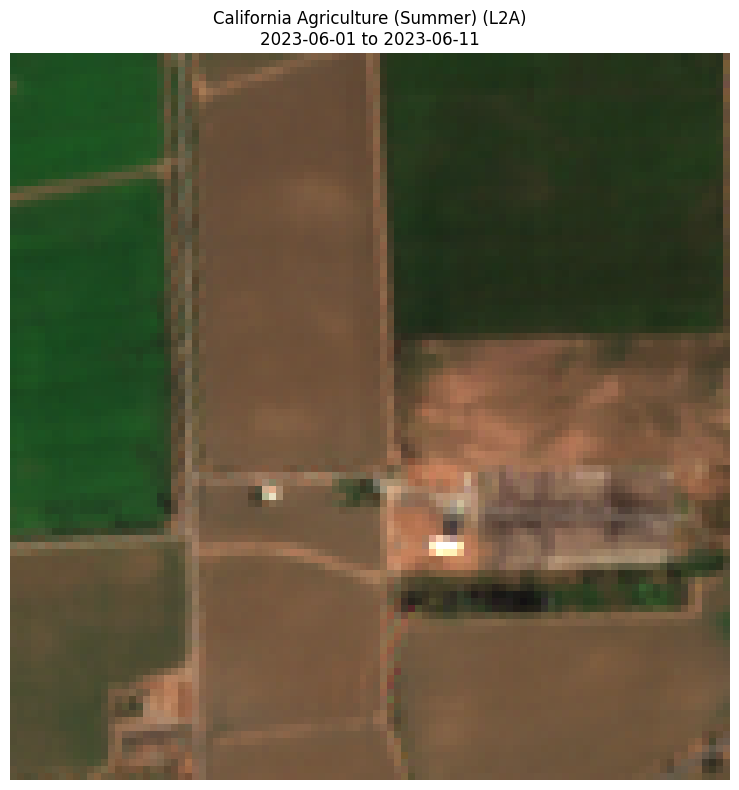


----------------------------------------------------------------------
California Agriculture (Summer) - L1C: 104×103 pixels, 0.0% masked (nodata=0.0)


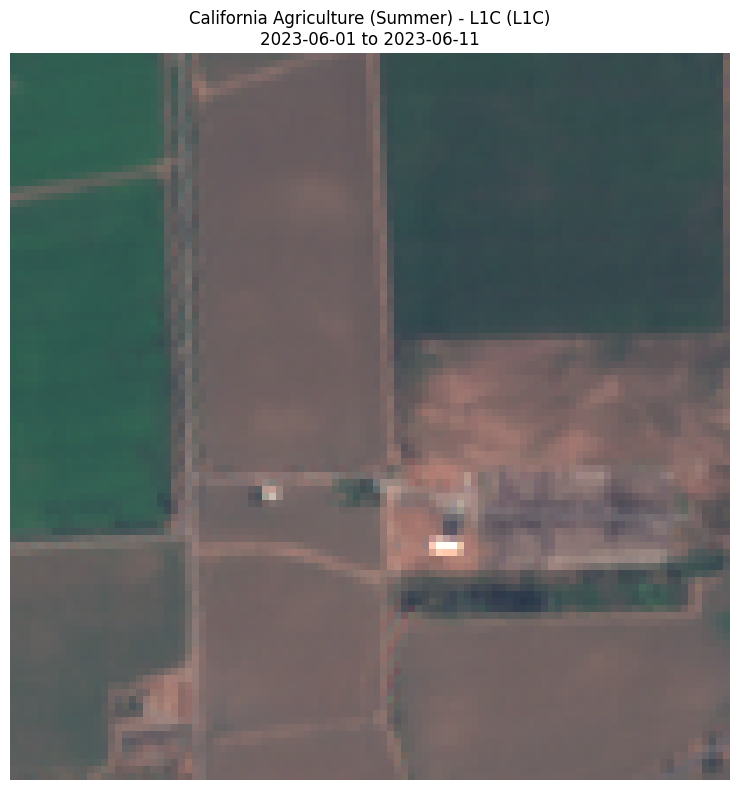


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L2A: 104×103 pixels, 0.0% masked (nodata=0.0)


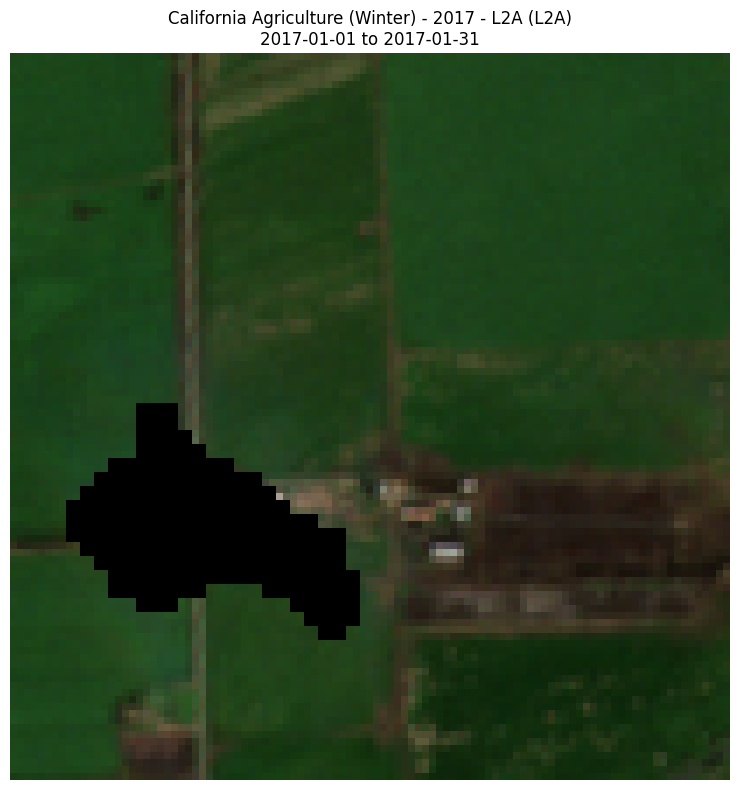


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L1C: 104×103 pixels, 0.0% masked (nodata=0.0)


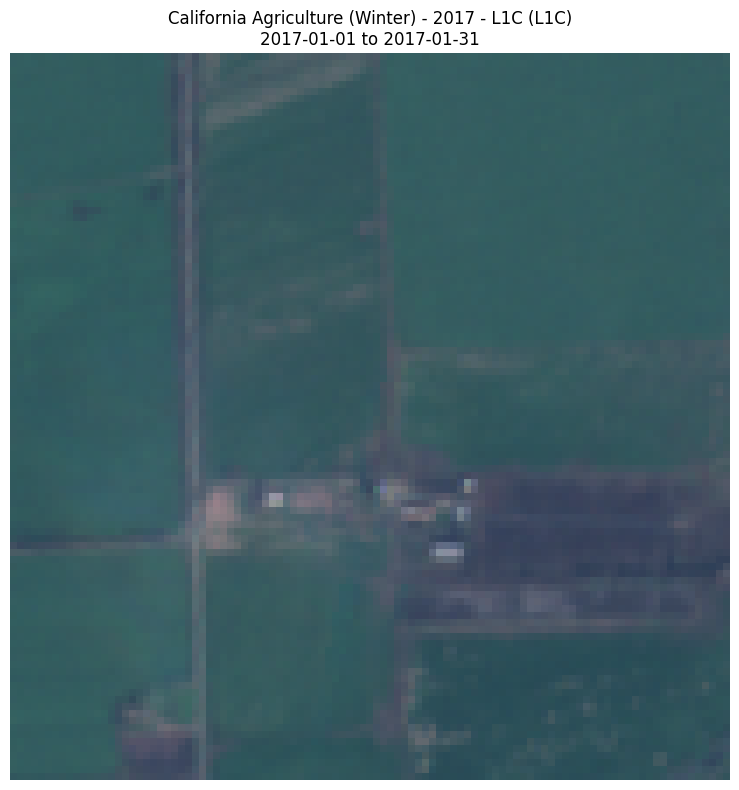

In [6]:
print("\n" + "="*70)
print("VISUALIZING DOWNLOADED IMAGES")
print("="*70)

for result in results:
    if result['success']:
        print("\n" + "-"*70)
        visualize_s2_image(result['file_path'], result['test'])
    else:
        print(f"\n✗ Skipping {result['test']['name']} (download failed)")

In [7]:
def visualize_s2_ndvi(file_path, test_info):
    """Visualize Sentinel-2 NDVI"""
    
    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return
    
    with rasterio.open(file_path) as src:
        # Read NIR (B8=band7) and Red (B4=band3)
        nir = src.read(7).astype(float)
        red = src.read(3).astype(float)
        
        # Use the file's nodata value
        nodata = src.nodata if src.nodata is not None else 0
        
        # Calculate NDVI
        ndvi = (nir - red) / (nir + red + 1e-8)
        
        # Mask nodata
        nodata_mask = (nir == nodata) | (red == nodata)
        ndvi = np.ma.masked_where(nodata_mask, ndvi)
        
        # Plot
        plt.figure(figsize=(8, 8))
        im = plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
        plt.colorbar(im, label='NDVI', fraction=0.046, pad=0.04)
        plt.title(f"NDVI: {test_info['name']} ({test_info['collection']})\n"
                  f"{test_info['start']} to {test_info['end']}")
        plt.axis('off')
        
        # Print stats
        valid_ndvi = ndvi.compressed()
        if len(valid_ndvi) > 0:
            print(f"{test_info['name']}: NDVI range [{valid_ndvi.min():.2f}, {valid_ndvi.max():.2f}], "
                  f"mean {valid_ndvi.mean():.2f}")
        
        plt.tight_layout()
        plt.show()


VISUALIZING NDVI

----------------------------------------------------------------------
California Agriculture (Summer): NDVI range [-0.22, 0.90], mean 0.44


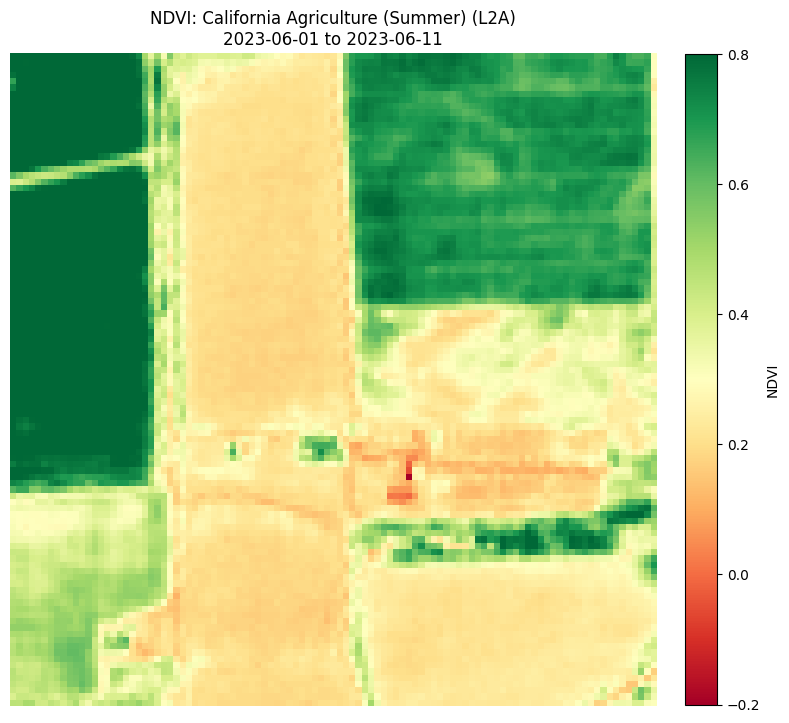


----------------------------------------------------------------------
California Agriculture (Summer) - L1C: NDVI range [-0.12, 0.79], mean 0.37


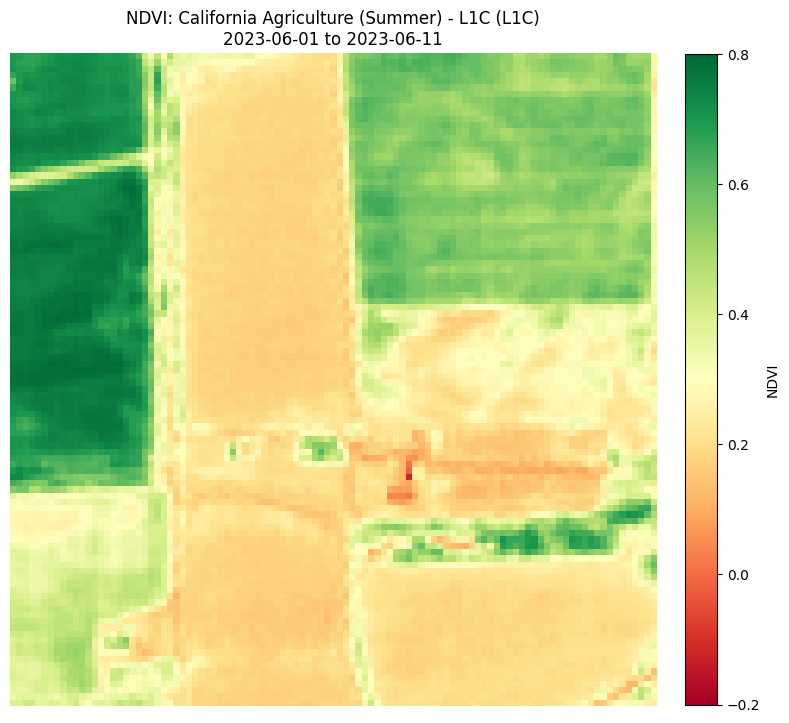


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L2A: NDVI range [0.01, 0.95], mean 0.78


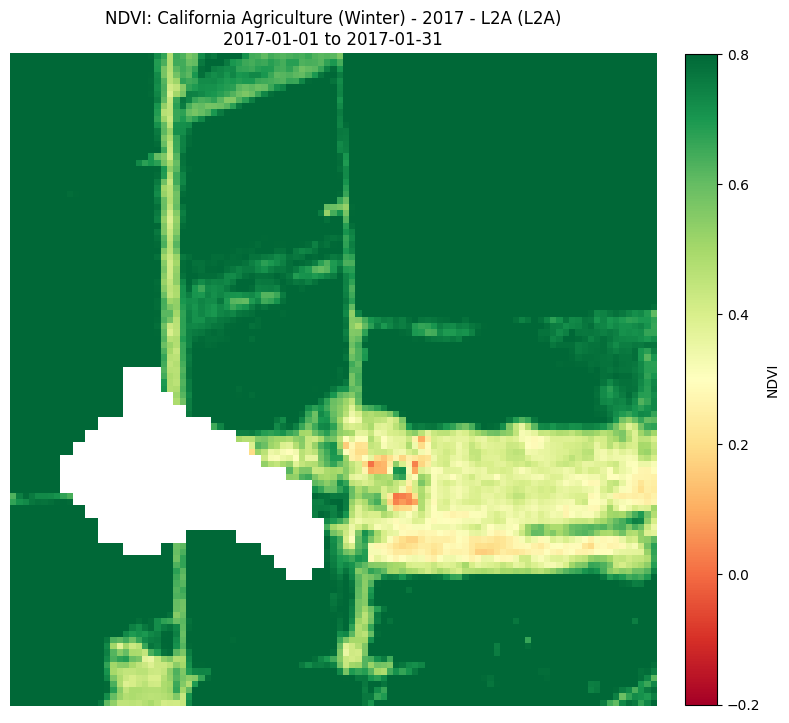


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L1C: NDVI range [0.06, 0.81], mean 0.66


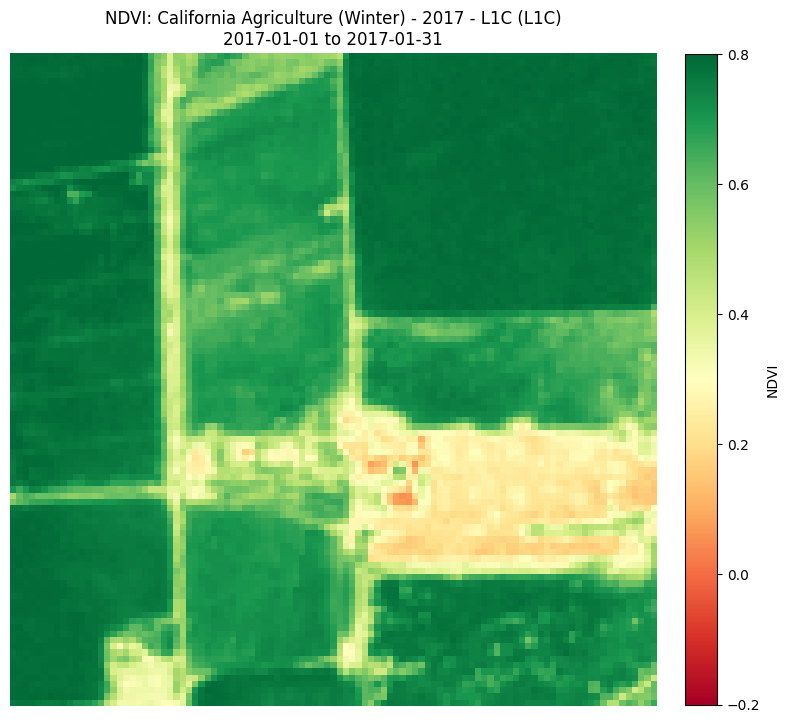

In [8]:
print("\n" + "="*70)
print("VISUALIZING NDVI")
print("="*70)

for result in results:
    if result['success']:
        print("\n" + "-"*70)
        visualize_s2_ndvi(result['file_path'], result['test'])
    else:
        print(f"\n✗ Skipping {result['test']['name']} (download failed)")